In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load dataset
data = load_breast_cancer()
df_bc = pd.DataFrame(data.data, columns=data.feature_names)
df_bc['target'] = data.target  # 0 = malignant, 1 = benign

In [3]:
# Train/test split
X = df_bc.drop("target", axis=1)
y = df_bc["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Train model
model_bc = RandomForestClassifier(random_state=42)
model_bc.fit(X_train, y_train)
print(classification_report(y_test, model_bc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [5]:
# 🧬 Focus Instance (Tumor Misclassification - Patient X)
focus_instance_bc = pd.DataFrame([{
    "mean radius": 13.80,
    "mean texture": 15.79,
    "mean perimeter": 90.43,
    "mean area": 584.1,
    "mean smoothness": 0.1007,
    "mean compactness": 0.1280,
    "mean concavity": 0.07789,
    "mean concave points": 0.05069,
    "mean symmetry": 0.1662,
    "mean fractal dimension": 0.06566,
    "radius error": 0.4101,
    "texture error": 1.074,
    "perimeter error": 2.635,
    "area error": 40.14,
    "smoothness error": 0.00541,
    "compactness error": 0.02204,
    "concavity error": 0.01664,
    "concave points error": 0.01185,
    "symmetry error": 0.02095,
    "fractal dimension error": 0.004902,
    "worst radius": 16.57,
    "worst texture": 20.86,
    "worst perimeter": 110.3,
    "worst area": 812.4,
    "worst smoothness": 0.1411,
    "worst compactness": 0.3542,
    "worst concavity": 0.2779,
    "worst concave points": 0.1383,
    "worst symmetry": 0.2589,
    "worst fractal dimension": 0.1030
}])

In [6]:
# Run prediction
pred = model_bc.predict(focus_instance_bc)
print("Prediction for Patient X:", "Benign → No Biopsy" if pred[0] == 1 else "Malignant → Action Needed")

Prediction for Patient X: Benign → No Biopsy


In [17]:
# Predicted probabilities for Patient X
probs = model_bc.predict_proba(focus_instance_bc)[0]

print(f"Probability of Malignant: {probs[0]:.2%}")
print(f"Probability of Benign: {probs[1]:.2%}")

Probability of Malignant: 15.00%
Probability of Benign: 85.00%


### SHAP

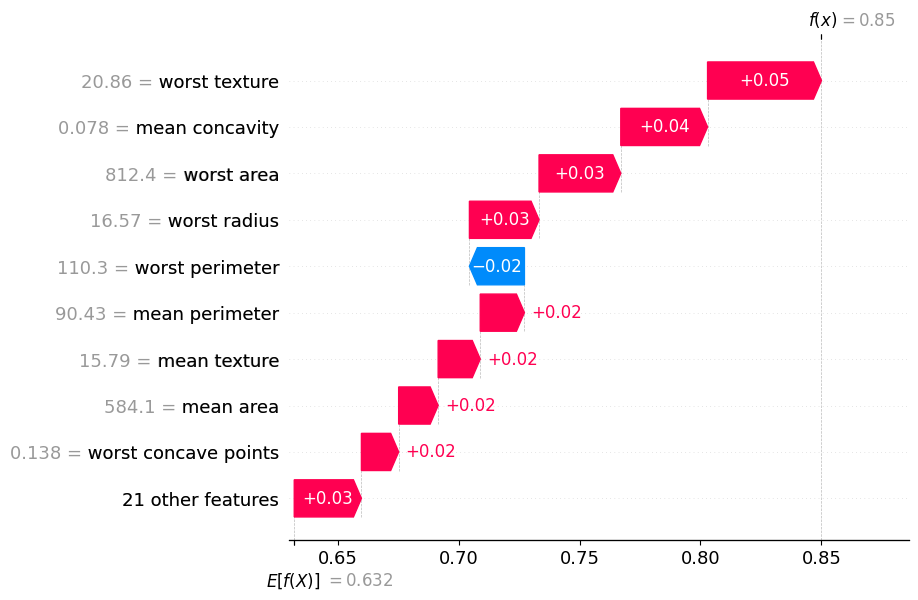

In [ ]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(model_bc)

# Calculate SHAP values for Patient X
shap_values = explainer(focus_instance_bc)

# SHAP waterfall plot for the predicted class: benign (class 1)
shap.plots.waterfall(shap_values[0, :, 1], max_display=10)
plt.show()

The SHAP plot shows that the model's prediction moved from a baseline benign probability of 0.632 → 0.85.

The strongest features pushing toward benign were:

- Worst texture = 20.86: +0.05
- Mean concavity = 0.078: +0.04
- Worst area = 812.4: +0.03
- Worst radius = 16.57: +0.03
- Mean perimeter = 90.43: +0.02
- Mean texture = 15.79: +0.02
- Mean area = 584.1: +0.02
- Worst concave points = 0.138: +0.02

There was one notable feature going the other way:

Worst perimeter = 110.3: −0.02 → malignant

Given the combination of measurements, the evidence looks more like the benign cases than the malignant cases.

### LIME

/Users/supriyanannapaneni/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


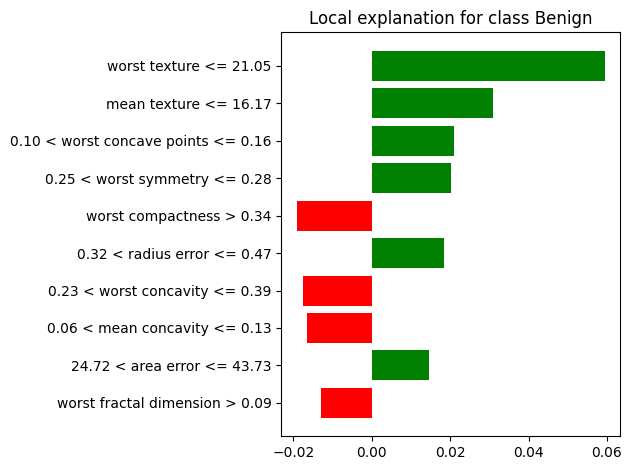

In [15]:
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Malignant", "Benign"],
    mode="classification",
    random_state=42
)

# Explain Patient X
lime_exp = lime_explainer.explain_instance(
    focus_instance_bc.iloc[0].values,
    model_bc.predict_proba,
    num_features=10
)

# Plot explanation
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

In [16]:
lime_exp.as_list()

[('worst texture <= 21.05', 0.05941258103516274),
 ('mean texture <= 16.17', 0.030873652932485035),
 ('0.10 < worst concave points <= 0.16', 0.02087692851952169),
 ('0.25 < worst symmetry <= 0.28', 0.02013128772240579),
 ('worst compactness > 0.34', -0.019188589064491272),
 ('0.32 < radius error <= 0.47', 0.018502335811254485),
 ('0.23 < worst concavity <= 0.39', -0.017672803686589595),
 ('0.06 < mean concavity <= 0.13', -0.016447052586695897),
 ('24.72 < area error <= 43.73', 0.01463979594765378),
 ('worst fractal dimension > 0.09', -0.012971714409634613)]

**Features supporting benign**

The strongest were:

- Worst texture ≤ 21.05	+0.0594	Strongly benign
- Mean texture ≤ 16.17	+0.0309	Benign
- 0.10 < worst concave points ≤ 0.16	+0.0209	Benign
- 0.25 < worst symmetry ≤ 0.28	+0.0201	Benign
- 0.32 < radius error ≤ 0.47	+0.0185	Benign
- 24.72 < area error ≤ 43.73	+0.0146	Benign



**Features pushing toward malignant**

LIME also identified several characteristics that worked against the benign classification:

- Worst compactness > 0.34	−0.0192	Malignant
- 0.23 < worst concavity ≤ 0.39	−0.0177	Malignant
- 0.06 < mean concavity ≤ 0.13	−0.0164	Malignant
- Worst fractal dimension > 0.09	−0.0130	Malignant

Both methods agree that texture-related features strongly support the benign classification.
SHAP & LIME: Worst texture -> benign
both explanation methods independently identify worst texture as the strongest local evidence supporting the benign prediction

SHAP: mean concavity -> +0.04 benign
LIME: 0.06 < mean concavity ≤ 0.13 → −0.016 malignant

explanations are model-dependent approximations.

### Global Feature Importance


In [ ]:

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_bc.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance.head(10))

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


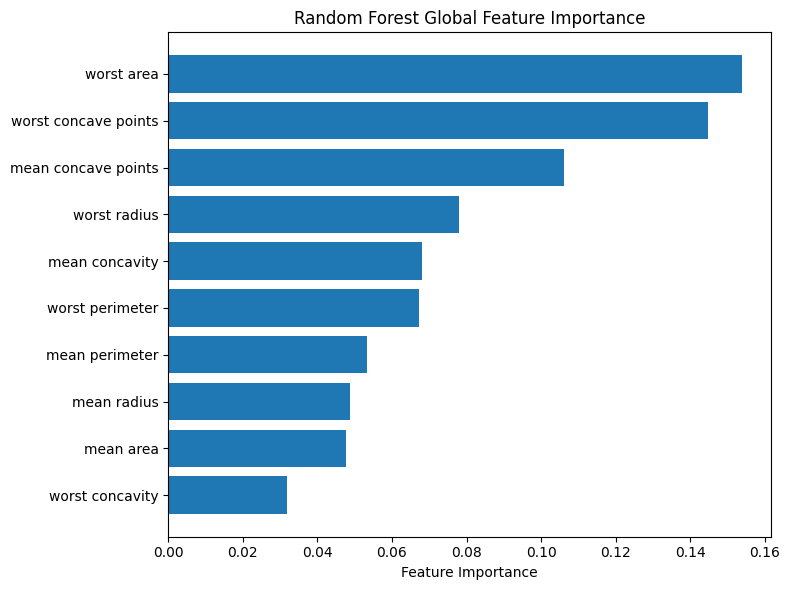

In [19]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Global Feature Importance")
plt.tight_layout()
plt.show()

Globally, the Random Forest relies heavily on tumor size and shape characteristics such as worst area, worst concave points, mean concave points, worst radius, and mean concavity. 

These same types of features appear in Patient X's local explanation, indicating that the model's decision was based on features that were important across the broader dataset rather than on an unusual or irrelevant variable.

### Confusion Matrix

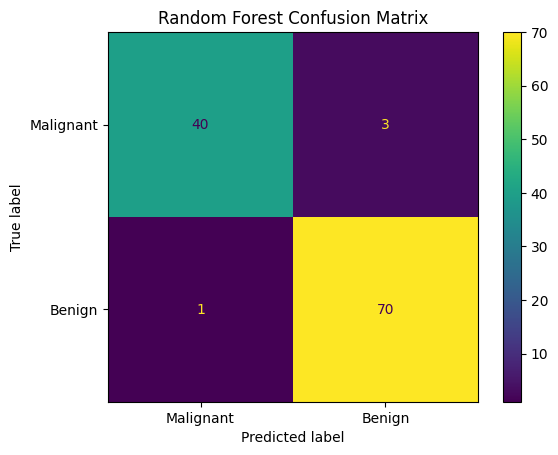

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model_bc.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

- 40 malignant tumors were correctly identified.
- 70 benign tumors were correctly identified.

- 3 malignant tumors were incorrectly classified as benign → these are false negatives.
- 1 benign tumor was incorrectly classified as malignant → false positive.

The confusion matrix shows that the Random Forest correctly classified 40 of 43 malignant tumors and 70 of 71 benign tumors. There were three false negatives, where malignant tumors were classified as benign, and one false positive, where a benign tumor was classified as malignant. 

Patient X represents the type of false-negative error demonstrated by the model. While the model performs well overall, the false negatives demonstrate that its learned feature patterns are not sufficient to identify every malignant tumor.

### FINAL SUMMARY:
**DEFENSE**

The defense acknowledges that Patient X was ultimately misclassified. However, the model's decision was not random. Both SHAP and LIME demonstrate that the prediction was based on meaningful combinations of tumor characteristics. Most prominently, both methods identify relatively low texture measurements as strong evidence supporting the benign classification. SHAP shows that the patient's overall feature profile increased the benign probability from 63.2% to 85%.

Importantly, the explanations also reveal conflicting evidence. Worst perimeter in SHAP and compactness and concavity conditions in LIME pushed the model toward malignancy. Therefore, the model did not simply ignore malignant indicators; rather, it weighted the competing evidence and ultimately classified the overall pattern as more consistent with benign tumors.

Given that the model learned these patterns from the broader dataset and achieved strong overall predictive performance, Patient X can be understood as an individual false negative rather than evidence that the model's decision was arbitrary or based on irrelevant features. At the same time, the disagreement between SHAP and LIME demonstrates that the model's reasoning is probabilistic and imperfect, highlighting why an AI prediction should not necessarily be the sole basis for a clinical decision such as whether to perform a biopsy.